<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/07_pytorch_experiment_tracking_exercise_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07. PyTorch Experiment Tracking Exercise Template

Welcome to the 07. PyTorch Experiment Tracking exercise template notebook.

> **Note:** There may be more than one solution to each of the exercises. This notebook only shows one possible example.

## Resources

1. These exercises/solutions are based on [section 07. PyTorch Transfer Learning](https://www.learnpytorch.io/07_pytorch_experiment_tracking/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/cO_r2FYcAjU).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

We'll need to make sure we have `torch` v.1.12+ and `torchvision` v0.13+.

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
import torch
import torchvision
# Get regular imports 
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular.going_modular.engine import train_test_step
from going_modular.going_modular.data_setup import create_dataloaders
import os

/home/jojo/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-11-20 12:28:31.748421: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-20 12:28:31.782306: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-20 1

In [2]:
 # Make sure we have a GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Download data

Using the same data from https://www.learnpytorch.io/07_pytorch_experiment_tracking/

In [3]:
# Get all the data of Food101 dataset
# from going_modular.going_modular.data_import import get_data
# get_data(url="http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz",
#          file="food_101")

In [4]:
import shutil

root = "data/food_101/food-101"
image_dir = os.path.join(root, "images")
splits = ["train", "test"]

# for split in splits:
#     # Create train/test directory
#     split_dir = os.path.join(root, split)
#     os.makedirs(split_dir, exist_ok=True)

#     # Get the path to the train/test text files
#     file = os.path.join(root, "meta", f"{split}.txt")

#     # Copy train/test text files
#     with open(file, "r") as f:
#         lines = [line.strip() for line in f]
    
#     for line in lines:
#         class_name, num_image = line.split("/")
#         path_image_origin = os.path.join(image_dir, f"{line}.jpg")
#         path_image_destination = os.path.join(split_dir, f"{line}.jpg")
#         # Make dir for each class
#         class_dir = os.path.join(split_dir, class_name)
#         os.makedirs(class_dir, exist_ok=True)
#         # Copy image from source file to dest file
#         shutil.copy(path_image_origin, path_image_destination)

In [5]:
# Setup training directory paths
train_dir_10_percent = "data/pizza_steak_sushi/train"
train_dir_20_percent = "data/pizza_steak_sushi_20_percent/train"
train_dir_full = os.path.join(root, "train")

# Setup testing directory paths (note: use the same test dataset for both to compare the results)
test_dir_10_percent = "data/pizza_steak_sushi/test"
test_dir_20_percent = "data/pizza_steak_sushi_20_percent/test"
test_dir_full = os.path.join(root, "test")

# Check the directories
print(f"Training directory 10%: {train_dir_10_percent}")
print(f"Training directory 20%: {train_dir_20_percent}")
print(f"Training directory full: {train_dir_full}")

print(f"Testing directory 10%: {test_dir_10_percent}")
print(f"Testing directory 20%: {test_dir_20_percent}")
print(f"Testing directory full: {test_dir_full}")

Training directory 10%: data/pizza_steak_sushi/train
Training directory 20%: data/pizza_steak_sushi_20_percent/train
Training directory full: data/food_101/food-101/train
Testing directory 10%: data/pizza_steak_sushi/test
Testing directory 20%: data/pizza_steak_sushi_20_percent/test
Testing directory full: data/food_101/food-101/test


###  Weights

In [6]:
# EfficientNet-B3
weights_efficientnet_b3 = torchvision.models.EfficientNet_B3_Weights.DEFAULT

# ConvNext-Tiny
weights_convnext_tiny = torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT

# DenseNet
weights_densnet = torchvision.models.DenseNet121_Weights.DEFAULT

### Transforms

In [7]:
# Auto_transform 
auto_transform_efficientnet_b3 = weights_efficientnet_b3.transforms()
auto_transform_convnext_tiny = weights_convnext_tiny.transforms()
auto_transform_densnet = weights_densnet.transforms()

# Data augmentation
data_augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide()
])

# Complete transform
complete_transform_efficientnet_b3 = transforms.Compose([
    data_augmentation_transform,
    auto_transform_efficientnet_b3
])

complete_transform_convnext_tiny = transforms.Compose([
    data_augmentation_transform,
    auto_transform_convnext_tiny
])

complete_transform_densnet = transforms.Compose([
    data_augmentation_transform,
    auto_transform_densnet
])

dict_of_transforms = {"efficientnet_b3_vanilla_data": auto_transform_efficientnet_b3, 
                      "convnext_tiny_vanilla_data": auto_transform_convnext_tiny, 
                      "densnet_vanilla_data": auto_transform_densnet, 
                      "efficientnet_b3_augmented_data": complete_transform_efficientnet_b3,
                      "convnext_tiny_augmented_data": complete_transform_convnext_tiny, 
                      "densnet_augmented_data": complete_transform_densnet}

### Models

In [8]:
import copy
# model efficientnet_b3
model_efficientnet_b3 = torchvision.models.efficientnet_b3(weights=weights_efficientnet_b3)
model_efficientnet_b3 = model_efficientnet_b3.to(device)

# model convnext_tiny
model_convnext_tiny = torchvision.models.convnext_tiny(weights=weights_convnext_tiny)
model_convnext_tiny = model_convnext_tiny.to(device)

# model resnet_50
model_densnet = torchvision.models.densenet121(weights=weights_densnet)
model_densnet = model_densnet.to(device)

models_10_percents = [copy.deepcopy(model_efficientnet_b3), copy.deepcopy(model_convnext_tiny), copy.deepcopy(model_densnet)]
models_20_percents = [copy.deepcopy(model_efficientnet_b3), copy.deepcopy(model_convnext_tiny), copy.deepcopy(model_densnet)]
models_full = [copy.deepcopy(model_efficientnet_b3), copy.deepcopy(model_convnext_tiny), copy.deepcopy(model_densnet)]

In [9]:
model_densnet

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [10]:
from going_modular.going_modular.utils import freeze_pretrained_model

def freeze_models(models, class_names, device):
    for model in models:
        freeze_pretrained_model(model, class_names, device)

### Turn data into DataLoaders 

In [11]:
from itertools import cycle

BATCH_SIZE = 32
frozen = False
dataloaders = {}
for name, transform in dict_of_transforms.items():
    # Create 10% training and test DataLoaders
    train_dataloader_10_percent, test_dataloader_10_percent, class_names = create_dataloaders(train_dir=train_dir_10_percent,
                                                                                              test_dir=test_dir_10_percent,
                                                                                              transform=transform,
                                                                                              batch_size=BATCH_SIZE)

    # Create 20% training and test DataLoaders
    train_dataloader_20_percent, test_dataloader_20_percent, class_names = create_dataloaders(train_dir=train_dir_20_percent,
                                                                                              test_dir=test_dir_20_percent,
                                                                                              transform=transform,
                                                                                              batch_size=BATCH_SIZE)
    
    # Create 100% training and test Dataloaders
    train_dataloader_full, test_dataloader_full, class_names_full = create_dataloaders(train_dir=train_dir_full,
                                                                                       test_dir=test_dir_full,
                                                                                       transform=transform,
                                                                                       batch_size=BATCH_SIZE)

    if not frozen:
        freeze_models(models_10_percents, class_names, device)
        freeze_models(models_20_percents, class_names, device)
        freeze_models(models_full, class_names_full, device)
        frozen = True

    dataloaders[name] = {"train_10_percent": train_dataloader_10_percent, 
                         "train_20_percent": train_dataloader_20_percent, 
                         "train_full": train_dataloader_full,
                         "test_10_percent": test_dataloader_10_percent,
                         "test_20_percent": test_dataloader_20_percent,
                         "test_full": test_dataloader_full,
                         "model_10_percent": next(cycle(models_10_percents)),
                         "model_20_percent": next(cycle(models_20_percents)),
                         "model_full": next(cycle(models_full))
                         }

# Find the number of samples/batches per dataloader (using the same test_dataloader for both experiments)
print(f"Number of batches of size {BATCH_SIZE} in 10 percent training data: {len(next(iter(dataloaders.values()))["train_10_percent"])}")
print(f"Number of batches of size {BATCH_SIZE} in 20 percent training data: {len(next(iter(dataloaders.values()))["train_20_percent"])}")
print(f"Number of batches of size {BATCH_SIZE} in full training data: {len(next(iter(dataloaders.values()))["train_full"])}")
print(f"Number of batches of size {BATCH_SIZE} in 10 percent testing data: {len(next(iter(dataloaders.values()))["test_10_percent"])}")
print(f"Number of batches of size {BATCH_SIZE} in 20 percent testing data: {len(next(iter(dataloaders.values()))["test_20_percent"])}")
print(f"Number of batches of size {BATCH_SIZE} in full testing data: {len(next(iter(dataloaders.values()))["test_full"])}")
print(f"Number of classes for dataset 10% and 20% : {len(class_names)}, class names: {class_names}")
print(f"Number of classes for dataset full : {len(class_names_full)}, class names: {class_names_full}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[300]
               resize_size=[320]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[300]
               resize_size=[320]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )
Train data:
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data/pizza_steak_sushi_20_percent/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[300]
               resize_size=[320]
      

In [10]:
print(summary(model_efficientnet_b3, input_size=(32, 3, 224, 224)))


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 3]                   --
├─Sequential: 1-1                                       [32, 1536, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 40, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 40, 112, 112]        (1,080)
│    │    └─BatchNorm2d: 3-2                            [32, 40, 112, 112]        (80)
│    │    └─SiLU: 3-3                                   [32, 40, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 24, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 24, 112, 112]        (2,298)
│    │    └─MBConv: 3-5                                 [32, 24, 112, 112]        (1,206)
│    └─Sequential: 2-3                                  [32, 32, 56, 56]          --
│    │    └─MBConv: 3-6                    

### Train models

In [12]:
sizes = ["10_percent", "20_percent", "full"]
for model_name_data_transform, dataloader in dataloaders.items():
    for s in sizes:
        train = f"train_{s}"
        model = f"model_{s}"
        test = f"test_{s}"
        results = train_test_step(model=dataloader[model],
                                train_dataloader=dataloader[train],
                                test_dataloader=dataloader[test],
                                loss_fn=nn.CrossEntropyLoss(),    
                                optimizer=torch.optim.Adam(dataloader[model].parameters(), lr=0.001),
                                device=device,
                                experiment_name=train,
                                model_name=model_name_data_transform,
                                epochs=5)

[INFO] Created SummaryWriter, saving to: runs/2025-11-20/train_10_percent/efficientnet_b3_vanilla_data...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/225 samples
Train loss: 1.096 | Train accuracy: 38.67%
Test loss: 0.973 | Test accuracy: 74.34%
Epoch 1
-------
Looked at 0/225 samples
Train loss: 0.942 | Train accuracy: 69.14%
Test loss: 0.910 | Test accuracy: 76.42%
Epoch 2
-------
Looked at 0/225 samples
Train loss: 0.825 | Train accuracy: 75.00%
Test loss: 0.751 | Test accuracy: 92.71%
Epoch 3
-------
Looked at 0/225 samples
Train loss: 0.705 | Train accuracy: 88.67%
Test loss: 0.738 | Test accuracy: 77.46%
Epoch 4
-------
Looked at 0/225 samples
Train loss: 0.751 | Train accuracy: 69.14%
Test loss: 0.751 | Test accuracy: 73.30%
Train time on cuda: 18.131 seconds
[INFO] Created SummaryWriter, saving to: runs/2025-11-20/train_20_percent/efficientnet_b3_vanilla_data...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/450 samples
Train loss: 0.976 | Train accuracy: 57.71%
Test loss: 0.796 | Test accuracy: 92.27%
Epoch 1
-------
Looked at 0/450 samples
Train loss: 0.695 | Train accuracy: 89.38%
Test loss: 0.593 | Test accuracy: 94.15%
Epoch 2
-------
Looked at 0/450 samples
Train loss: 0.564 | Train accuracy: 88.12%
Test loss: 0.492 | Test accuracy: 95.06%
Epoch 3
-------
Looked at 0/450 samples
Train loss: 0.465 | Train accuracy: 90.21%
Test loss: 0.425 | Test accuracy: 95.97%
Epoch 4
-------
Looked at 0/450 samples
Train loss: 0.420 | Train accuracy: 91.46%
Test loss: 0.368 | Test accuracy: 94.72%
Train time on cuda: 23.917 seconds
[INFO] Created SummaryWriter, saving to: runs/2025-11-20/train_full/efficientnet_b3_vanilla_data...


...

Epoch 0
-------
Looked at 0/225 samples
Train loss: 0.223 | Train accuracy: 94.14%
Test loss: 8.752 | Test accuracy: 85.61%
Epoch 1
-------
Looked at 0/225 samples
Train loss: 0.241 | Train accuracy: 95.70%
Test loss: 0.389 | Test accuracy: 88.73%
Epoch 2
-------
Looked at 0/225 samples
Train loss: 0.284 | Train accuracy: 96.09%
Test loss: 0.298 | Test accuracy: 89.77%
Epoch 3
-------
Looked at 0/225 samples
Train loss: 0.267 | Train accuracy: 95.31%
Test loss: 0.470 | Test accuracy: 82.58%
Epoch 4
-------
Looked at 0/225 samples
Train loss: 0.440 | Train accuracy: 81.25%
Test loss: 0.309 | Test accuracy: 91.76%
Train time on cuda: 38.314 seconds
[INFO] Created SummaryWriter, saving to: runs/2025-11-20/train_20_percent/densnet_augmented_data...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/450 samples
Train loss: 0.187 | Train accuracy: 93.96%
Test loss: 0.252 | Test accuracy: 91.65%
Epoch 1
-------
Looked at 0/450 samples
Train loss: 0.202 | Train accuracy: 93.33%
Test loss: 0.228 | Test accuracy: 93.12%
Epoch 2
-------
Looked at 0/450 samples
Train loss: 0.186 | Train accuracy: 94.38%
Test loss: 0.242 | Test accuracy: 92.22%
Epoch 3
-------
Looked at 0/450 samples
Train loss: 0.175 | Train accuracy: 95.00%
Test loss: 0.196 | Test accuracy: 92.27%
Epoch 4
-------
Looked at 0/450 samples
Train loss: 0.222 | Train accuracy: 91.88%
Test loss: 0.228 | Test accuracy: 91.59%
Train time on cuda: 41.437 seconds
[INFO] Created SummaryWriter, saving to: runs/2025-11-20/train_full/densnet_augmented_data...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
-------
Looked at 0/75750 samples
Looked at 12800/75750 samples
Looked at 25600/75750 samples
Looked at 38400/75750 samples
Looked at 51200/75750 samples
Looked at 64000/75750 samples
Train loss: 2.029 | Train accuracy: 50.06%
Test loss: 1.749 | Test accuracy: 55.75%
Epoch 1
-------
Looked at 0/75750 samples
Looked at 12800/75750 samples
Looked at 25600/75750 samples
Looked at 38400/75750 samples
Looked at 51200/75750 samples
Looked at 64000/75750 samples
Train loss: 2.010 | Train accuracy: 50.31%
Test loss: 2.080 | Test accuracy: 55.95%
Epoch 2
-------
Looked at 0/75750 samples
Looked at 12800/75750 samples
Looked at 25600/75750 samples
Looked at 38400/75750 samples
Looked at 51200/75750 samples
Looked at 64000/75750 samples
Train loss: 2.007 | Train accuracy: 50.40%
Test loss: 1.752 | Test accuracy: 55.65%
Epoch 3
-------
Looked at 0/75750 samples
Looked at 12800/75750 samples
Looked at 25600/75750 samples
Looked at 38400/75750 samples
Looked at 51200/75750 samples
Looked at 

### Load result on tensorboard

In [13]:
%load_ext tensorboard
%tensorboard --logdir=runs --host=localhost --port=6006

Launching TensorBoard...

In [78]:
from going_modular.going_modular.utils import save_model, load_model
model_name = ["efficientnet_b3", "convnext_tiny", "densnet"]
model_data = {
    "10_percent": models_10_percents,
    "20_percent": models_20_percents,
    "full": models_full
    }

for size, models in model_data.items():
    for model, name in zip(models, model_name):
        save_model(model, "models", f"{size}_{name}.pth")

[INFO] Saving model to: models/10_percent_efficientnet_b3.pth
[INFO] Saving model to: models/10_percent_convnext_tiny.pth
[INFO] Saving model to: models/10_percent_densnet.pth
[INFO] Saving model to: models/20_percent_efficientnet_b3.pth
[INFO] Saving model to: models/20_percent_convnext_tiny.pth
[INFO] Saving model to: models/20_percent_densnet.pth
[INFO] Saving model to: models/full_efficientnet_b3.pth
[INFO] Saving model to: models/full_convnext_tiny.pth
[INFO] Saving model to: models/full_densnet.pth


### Data visualization

In [87]:
from going_modular.going_modular.predict import predict_image, plot_predictions
from going_modular.going_modular.utils import img_denorm
import going_modular.going_modular.predict
import importlib
importlib.reload(going_modular.going_modular.predict)

<module 'going_modular.going_modular.predict' from '/home/jojo/Bureau/Portfolio/Deep Learning/PyTorch/Classification/Computer vision/going_modular/going_modular/predict.py'>

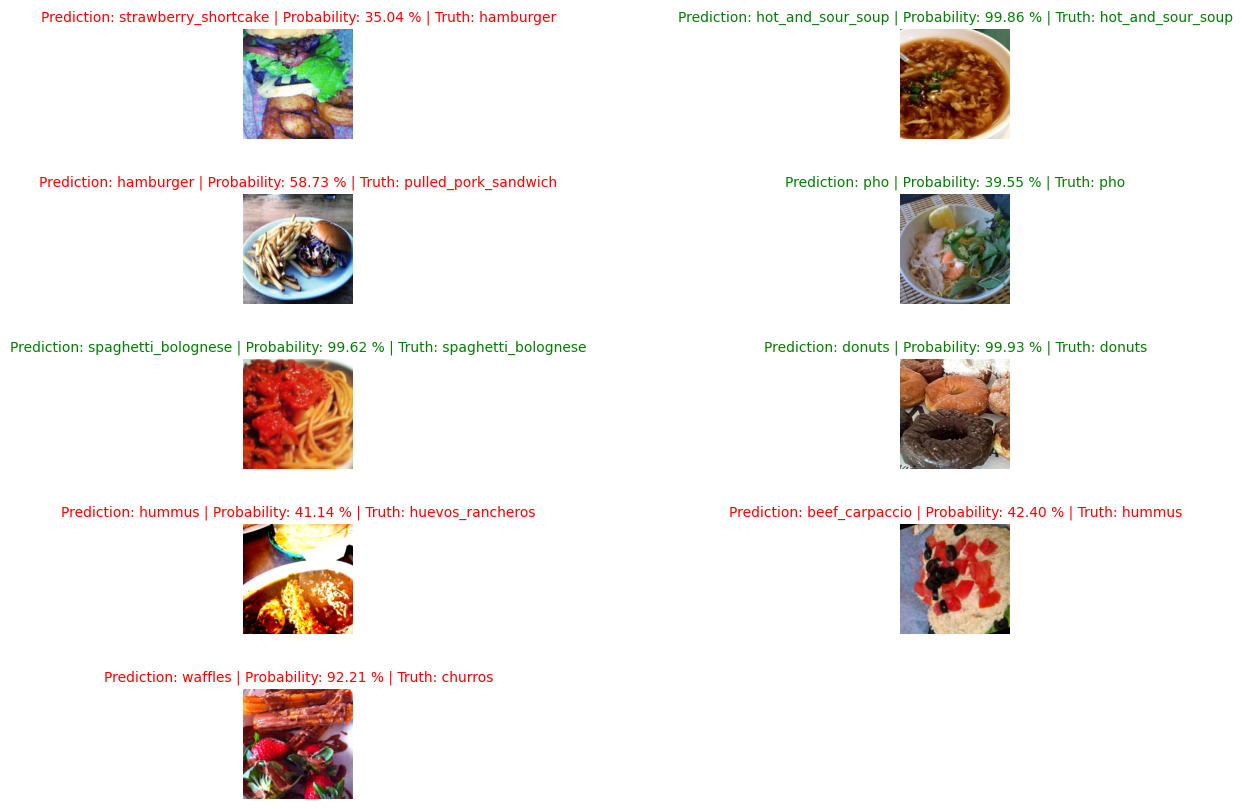

In [81]:
going_modular.going_modular.predict.plot_predictions(device, 
                                                     test_dataloader_full, 
                                                     models_full[0], 
                                                     img_denorm, 
                                                     l_size=15, 
                                                     h_size=10, 
                                                     rows=5, 
                                                     h_space=0.5,
                                                     cols=2)

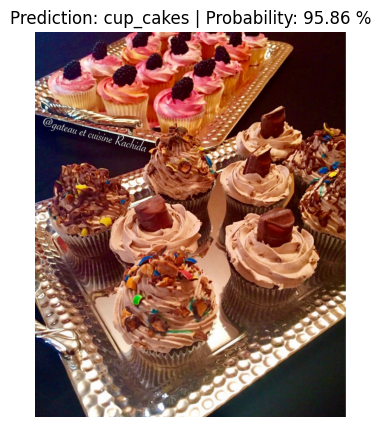

In [90]:
predict_image("images/cupcakes.jpg", models_full[0], class_names_full, device, auto_transform_efficientnet_b3)